In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader
import torch

import sys
import os

sys.path.append(os.path.abspath(".."))
from model.lstm import LoanDefaultModel, LoanDefaultDataset

## 1. Loading the model & data

In [2]:
data = np.load("../datasets/padded_credit_default_prediction_dataset/credit_risk_dataset_5k_padded.npz", allow_pickle=True)

X_padded      = data["X_padded"]
y_padded      = data["y_padded"]
customer_ids  = data["customer_ids"]
feature_cols  = data["feature_cols"]

In [3]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test, id_temp, id_test= train_test_split(
    X_padded, y_padded, customer_ids,
    test_size=0.15,
    random_state=1024,
    stratify=y_padded
)
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X_temp, y_temp, id_temp,
    test_size=0.18,
    random_state=1024,
    stratify=y_temp
)

print(f"Train: {len(X_train):,} loans (Class 1: {(y_train==1).sum()})")
print(f"Val:   {len(X_val):,} loans (Class 1: {(y_val==1).sum()})")
print(f"Test:  {len(X_test):,} loans (Class 1: {(y_test==1).sum()})")

Train: 2,710 loans (Class 1: 326)
Val:   595 loans (Class 1: 71)
Test:  584 loans (Class 1: 70)


In [4]:
batch_size = 128

# train_dataset = LoanDefaultDataset(X_train, y_train)
# val_dataset = LoanDefaultDataset(X_val, y_val)
test_dataset = LoanDefaultDataset(X_test, y_test)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
device = 'cpu'
model = LoanDefaultModel(input_size=33, hidden_size=32)
model.load_state_dict(torch.load('../model/best_model.pth'))
model.eval()
model = model.to(device)

all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
all_preds = np.array(all_preds).flatten()
all_probs = np.array(all_probs).flatten()
all_targets = np.array(all_targets).flatten()

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_pred=all_preds, y_true=all_targets))

              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95       514
         1.0       0.61      0.77      0.68        70

    accuracy                           0.91       584
   macro avg       0.79      0.85      0.82       584
weighted avg       0.93      0.91      0.92       584



## 2. Explainability

In [7]:
from captum.attr import IntegratedGradients
model.eval()
ig = IntegratedGradients(model)
X_test.shape

/Users/haoyuli/Desktop/Master_Semester_2/Agentic_Explainable_AI_PwC/.agent_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(584, 13, 33)

In [8]:
X_np = X_test
N, T, F = X_np.shape

all_attr_list = []

for i in range(N):
    x_i = torch.tensor(X_np[i], dtype=torch.float32).unsqueeze(0)  # (1, T, F)
    baseline_i = torch.zeros_like(x_i)
    attr_i, _ = ig.attribute(
        x_i,
        baselines=baseline_i,
        target=0,
        n_steps=50,
        return_convergence_delta=True
    )
    all_attr_list.append(attr_i.squeeze(0).detach().cpu())   # (T, F)

all_attr = torch.stack(all_attr_list, dim=0)   # (N, T, F)
print("all_attr shape:", all_attr.shape)

all_attr shape: torch.Size([584, 13, 33])


### Global Feature-Level && Time-Level Importance

all_attr shape: torch.Size([584, 13, 33])


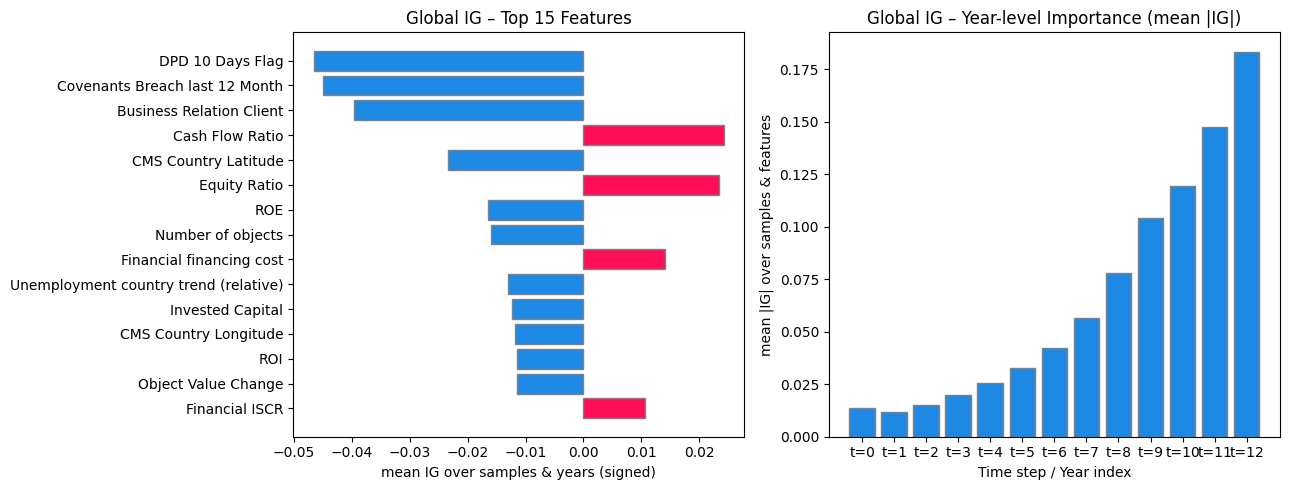

In [9]:
model.eval()
ig = IntegratedGradients(model)

X_np = X_test
N, T, F = X_np.shape

all_attr_list = []

for i in range(N):
    x_i = torch.tensor(X_np[i], dtype=torch.float32).unsqueeze(0)  # (1, T, F)
    baseline_i = torch.zeros_like(x_i)
    attr_i, _ = ig.attribute(
        x_i,
        baselines=baseline_i,
        target=0,
        n_steps=50,
        return_convergence_delta=True
    )
    all_attr_list.append(attr_i.squeeze(0).detach().cpu())   # (T, F)

all_attr = torch.stack(all_attr_list, dim=0)   # (N, T, F)
print("all_attr shape:", all_attr.shape)

# 1) Feature-level Importance
global_feat_imp_signed = all_attr.mean(dim=(0, 1)).numpy()   # (F,)

if 'feature_cols' in globals() and len(feature_cols) == F:
    global_feat_labels = feature_cols
else:
    global_feat_labels = [f"f={i}" for i in range(F)]

# Top 15 Features
top_k_global = min(15, F)
sorted_idx_global = np.argsort(np.abs(global_feat_imp_signed))[::-1]
top_idx_global = sorted_idx_global[:top_k_global]

top_vals_global = global_feat_imp_signed[top_idx_global]
top_labels_global = np.array(global_feat_labels)[top_idx_global]

# 2) Year-level
global_year_imp_abs = all_attr.abs().mean(dim=(0, 2)).numpy()  # (T,)
x_years = np.arange(T)

# 3) Ploting
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: features (Red: Increase default rate; Blue: Decrease default rate)
colors_feat = np.where(top_vals_global > 0, '#ff0d57', '#1e88e5')
axes[0].barh(np.arange(top_k_global), top_vals_global,
             color=colors_feat, edgecolor='gray')
axes[0].set_yticks(np.arange(top_k_global))
axes[0].set_yticklabels(top_labels_global)
axes[0].invert_yaxis()
axes[0].set_xlabel("mean IG over samples & years (signed)")
axes[0].set_title(
    f"Global IG – Top {top_k_global} Features"
)

# Right: years (absolute importance)
axes[1].bar(x_years, global_year_imp_abs, color='#1e88e5', edgecolor='gray')
axes[1].set_xticks(x_years)
axes[1].set_xticklabels([f"t={i}" for i in x_years])
axes[1].set_xlabel("Time step / Year index")
axes[1].set_ylabel("mean |IG| over samples & features")
axes[1].set_title("Global IG – Year-level Importance (mean |IG|)")

plt.tight_layout()
plt.show()

### Local Explainability

In [10]:
assert id_test.shape == (584,)
pos = np.random.randint(id_test.shape[0])
id = id_test[pos] # np.random.choice(id_test)

input_tensor = torch.tensor(X_test[pos], dtype=torch.float32).unsqueeze(0)
baseline = torch.zeros_like(input_tensor)

attributions, delta = ig.attribute(
    input_tensor,
    baselines=baseline,
    target=0,
    n_steps=50,
    return_convergence_delta=True
)

attr = attributions.squeeze(0).detach().cpu()
seq_len, num_features = attr.shape
print("attr shape:", attr.shape)

attr shape: torch.Size([13, 33])


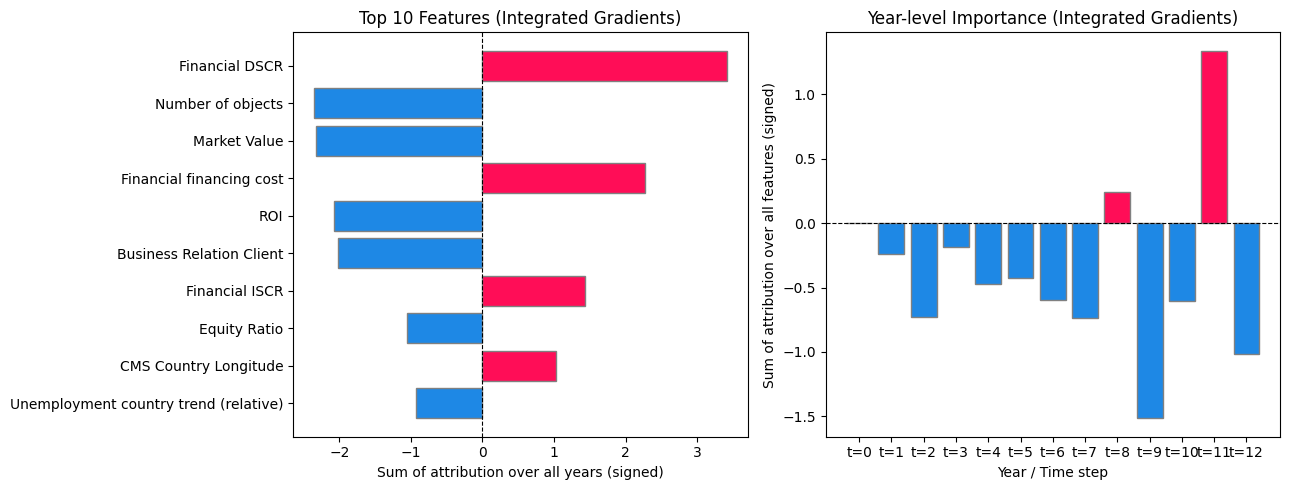

In [11]:
# Use signed attribution values
feature_importance_signed = attr.sum(dim=0).numpy()
feature_importance_abs = np.abs(feature_importance_signed)

feat_labels = feature_cols

sorted_idx = np.argsort(feature_importance_abs)[::-1]
top_k = 10
top_idx = sorted_idx[:top_k]

top_vals_signed = feature_importance_signed[top_idx]
top_labels = np.array(feat_labels)[top_idx]

year_importance_signed = attr.sum(dim=1).numpy()
x_years = np.arange(seq_len)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: positive right (red), negative left (blue)
colors_feat = np.where(top_vals_signed > 0, '#ff0d57', '#1e88e5')
axes[0].barh(np.arange(top_k), top_vals_signed, color=colors_feat, edgecolor='gray')
axes[0].set_yticks(np.arange(top_k))
axes[0].set_yticklabels(top_labels)
axes[0].invert_yaxis()
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("Sum of attribution over all years (signed)")
axes[0].set_title(f"Top {top_k} Features (Integrated Gradients)")

# Right: positive up (red), negative down (blue)
colors_year = np.where(year_importance_signed > 0, '#ff0d57', '#1e88e5')
axes[1].bar(x_years, year_importance_signed, color=colors_year, edgecolor='gray')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(x_years)
axes[1].set_xticklabels([f"t={i}" for i in x_years])
axes[1].set_xlabel("Year / Time step")
axes[1].set_ylabel("Sum of attribution over all features (signed)")
axes[1].set_title("Year-level Importance (Integrated Gradients)")

plt.tight_layout()
plt.show()

In [12]:
# for i in range(X_test[pos].shape[0]):
#     if np.allclose(X_test[pos][i], 0):
#         print(f"Year {i+1} is padded")

In [13]:
target = all_targets[pos]
pred = all_preds[pos]
probs = all_probs[pos]
logit = model(input_tensor)

print(f"Sample ID        : {id}")
print(f"Ground Truth     : {target}")
print(f"Model Prediction : {pred}")
print(f"Probability (p)  : {probs:.4f}")
print(f"Logit (raw)      : {logit.item():.4f}")
print("="*50)

Sample ID        : 12408
Ground Truth     : 0.0
Model Prediction : 0.0
Probability (p)  : 0.0139
Logit (raw)      : -4.2619


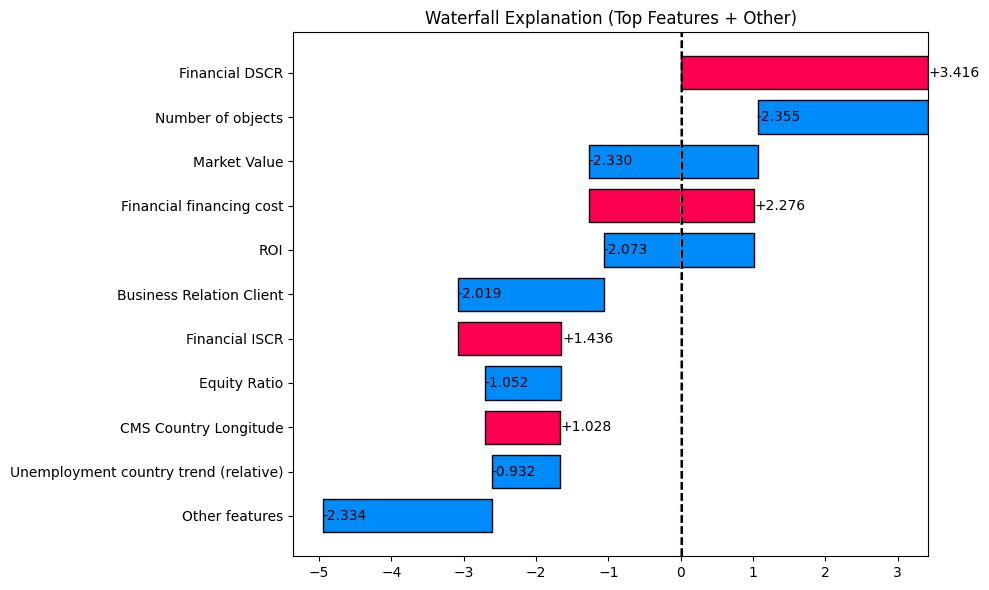

In [14]:
values = input_tensor.squeeze()[-1].numpy()    # shape = (features,)

# IG contributions 
contrib_full = feature_importance_signed.copy()
names_full = np.array(feature_cols)
values_full = values.copy()

# Sort by absolute importance
top_k = 10
idx = np.argsort(np.abs(contrib_full))[::-1]

top_idx = idx[:top_k]
other_idx = idx[top_k:]

# Top-K
contrib = contrib_full[top_idx]
names = names_full[top_idx]
values = values_full[top_idx]

# "Other features" combined
contrib_other = contrib_full[other_idx].sum()
if contrib_other != 0:
    contrib = np.append(contrib, contrib_other)
    names = np.append(names, "Other features")
    values = np.append(values, np.nan)

# Cumulative sum for waterfall
baseline = 0
final_output = float(probs)
cumulative = baseline + np.cumsum(contrib)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(names))
colors = np.where(contrib > 0, "#ff0051", "#008bfb")

for i in range(len(names)):
    x_start = cumulative[i] - contrib[i]
    x_end = cumulative[i]

    ax.barh(
        i,
        contrib[i],
        left=x_start,
        color=colors[i],
        edgecolor="black",
        height=0.75
    )

    ax.text(
        x_end + 0.01 * np.sign(contrib[i]),
        i,
        f"{contrib[i]:+.3f}",
        va="center",
        fontsize=10
    )

# y-axis labels (feature names only)
ax.set_yticks(y_pos)
ax.set_yticklabels(names)

ax.set_title("Waterfall Explanation (Top Features + Other)")
ax.axvline(baseline, color="gray", linestyle="--")
ax.axvline(final_output, color="black", linestyle="--")

# ax.text(final_output, len(names)+0.3, f"f(x) = {final_output:.3f}", fontsize=11)
# ax.text(baseline, len(names)+0.3, f"Baseline = {baseline:.3f}", fontsize=11, color="gray")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
contrib_full = feature_importance_signed.copy()
names_full = np.array(feature_cols)

# sort by |contrib|
idx = np.argsort(np.abs(contrib_full))[::-1]

top_k = 10
top_idx = idx[:top_k]
other_idx = idx[top_k:]

# top-K
top_contrib = contrib_full[top_idx]
top_names = names_full[top_idx]

# others
other_contrib = contrib_full[other_idx].sum()
target = all_targets[pos]
pred = all_preds[pos]
probs = all_probs[pos]
logit = model(input_tensor)
baseline = 0   # IG baseline

## Output Report
print("="*60)
print("                  MODEL PREDICTION SUMMARY")
print("="*60)
print(f"Sample ID             : {id}")
print(f"Ground Truth (y)      : {target}")
print(f"Model Prediction      : {pred}")
print(f"Probability p(y=1)    : {probs:.4f}")
print(f"Logit (raw score)     : {logit.item():.4f}")
print("-"*60)
print(f"Baseline (IG)         : {baseline:.4f}")
print(f"Final Output f(x)     : {probs:.4f}")
print("="*60)

# TOP FEATURE CONTRIBUTIONS
print("Top Feature Contributions (Integrated Gradients):")
print("-"*60)

for name, c in zip(top_names, top_contrib):
    sign = "+" if c > 0 else ""
    print(f"{name:<35} {sign}{c:.4f}")
sign_other = "+" if other_contrib > 0 else ""
print(f"{'Other features (combined)':<35} {sign_other}{other_contrib:.4f}")
print("="*60)

                  MODEL PREDICTION SUMMARY
Sample ID             : 12408
Ground Truth (y)      : 0.0
Model Prediction      : 0.0
Probability p(y=1)    : 0.0139
Logit (raw score)     : -4.2619
------------------------------------------------------------
Baseline (IG)         : 0.0000
Final Output f(x)     : 0.0139
Top Feature Contributions (Integrated Gradients):
------------------------------------------------------------
Financial DSCR                      +3.4162
Number of objects                   -2.3551
Market Value                        -2.3304
Financial financing cost            +2.2758
ROI                                 -2.0734
Business Relation Client            -2.0185
Financial ISCR                      +1.4361
Equity Ratio                        -1.0523
CMS Country Longitude               +1.0275
Unemployment country trend (relative) -0.9317
Other features (combined)           -2.3345
